In [3]:
#1. Import required libraries 
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt

In [2]:
#2. Choose a target Y
#3. Create the data matrices for X (input) and Y (target)
#4. Divide the dataset into training and test, as 80% training and 20% testing dataset.
df_penguin = pd.read_csv('./preprocessed_datasets/penguins_preprocessed.csv')
df_penguin_shuffled = df_penguin.sample(frac=1).reset_index(drop=True)

split_index_penguin = int(0.8 * len(df_penguin_shuffled))

X_penguin = df_penguin_shuffled.drop(columns=['island_Biscoe', 'island_Dream', 'island_Torgersen'])
y_penguin = df_penguin_shuffled['island_Biscoe']

X_train_penguin = X_penguin[:split_index_penguin]
y_train_penguin = y_penguin[:split_index_penguin]
X_test_penguin = X_penguin[split_index_penguin:]
y_test_penguin = y_penguin[split_index_penguin:]

In [3]:
#5. Print the shape of X_train, y_train, X_test, y_test
print('shape of penguin X train', X_train_penguin.shape)
print('shape of penguin Y train', y_train_penguin.shape)
print('shape of penguin X test', X_test_penguin.shape)
print('shape of penguin Y test', y_test_penguin.shape)

shape of penguin X train (246, 7)
shape of penguin Y train (246,)
shape of penguin X test (62, 7)
shape of penguin Y test (62,)


In [7]:
#6. Recommended structure of your code to define logistic regression:
class LogitRegression():
    def __init__(self, learning_rate=0.01, iterations=200):
    # Takes as an input hyperparameters: learning rate and the number of iterations.
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
    # Define a sigmoid function
        z = np.array(z, dtype=float)
        return 1 / (1 + np.exp(-z))
    
    def cost(self, y, y_hat):
    # Loss function for Logistic Regression can be defined
        N = y.shape[0]
        # adjust y_hat to avoid log(0)
        y_hat = np.clip(y_hat, 1e-10, 1 - 1e-10)
        cost = - (1/N) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return cost
    
    def gradient_descent(self, X, y, y_hat):
    # Define current prediction y_hat for logistic regression
        N = X.shape[0]
        delta = (y_hat - y)
        dw = (1/N) * np.dot(X.T, delta)
        db = (1/N) * np.sum(delta)
        self.weights = np.array(self.weights, dtype=float)
        dw = np.array(dw, dtype=float)
        # Update
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
    
    def fit(self, X, y):
    # Initialize weights
        N, d = X.shape
        self.weights = np.random.rand(d)
        self.bias = 0

        for i in range(self.iterations):
            # Call gradient_descent function
            # Call cost function and keep it in an array
            z = np.dot(self.weights, X.T) + self.bias
            y_hat = self.sigmoid(z)
            self.gradient_descent(X, y, y_hat)
            cost = self.cost(y, y_hat)
            self.loss_history.append(cost)
             
    def predict(self, X):
        z = np.dot(self.weights, X.T) + self.bias
        y_hat = self.sigmoid(z)
        y_pred = [1 if i >= 0.5 else 0 for i in y_hat]
        return np.array(y_pred)


In [31]:
#7. Train the model:
#9. Make a prediction on test dataset by counting how many correct/incorrect predictions your model makes and print your accuracy.(above 64%)
warnings.filterwarnings('ignore')
hyper_parameters1 = [{'learning_rate': 1e-2, 'iterations': 500}, {'learning_rate': 1e-2, 'iterations': 2000}, {'learning_rate': 1e-2, 'iterations': 5000}, {'learning_rate': 1e-3, 'iterations': 10000}, {'learning_rate': 1e-3, 'iterations': 50000}]
best_accuracy = 0
best_weights = None
best_bias = None
best_loss_history = None
models1=[]
for parameter in hyper_parameters1:
    model = LogitRegression(learning_rate=parameter['learning_rate'], iterations=parameter['iterations'])
    model.fit(X_train_penguin, y_train_penguin)
    model_pred = model.predict(X_test_penguin)
    model_accuracy = np.sum(y_test_penguin == model_pred) / len(y_test_penguin)
    print('Parameters is', parameter, ', and the accuracy of the model is', model_accuracy)
    models1.append({'param': parameter, 'loss_history': model.loss_history})
    if model_accuracy > best_accuracy:
        best_weights = model.weights
        best_bias = model.bias
        best_loss_history = model.loss_history
        best_accuracy = model_accuracy

Parameters is {'learning_rate': 0.01, 'iterations': 500} , and the accuracy of the model is 0.8387096774193549
Parameters is {'learning_rate': 0.01, 'iterations': 2000} , and the accuracy of the model is 0.8709677419354839
Parameters is {'learning_rate': 0.01, 'iterations': 5000} , and the accuracy of the model is 0.8709677419354839
Parameters is {'learning_rate': 0.001, 'iterations': 10000} , and the accuracy of the model is 0.8709677419354839
Parameters is {'learning_rate': 0.001, 'iterations': 50000} , and the accuracy of the model is 0.8709677419354839


In [24]:
#8. Save the weights of the model, that returns the highest accuracy as pickle file.    
weights_dic={}
bias_dic={}

In [31]:
weights_dic['penguin'] = best_weights
bias_dic['penguin'] = best_bias

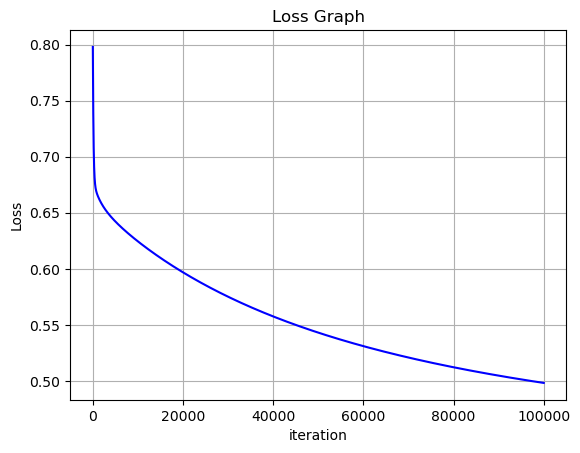

In [13]:
#10. Plot the loss graph and print out the loss values over each iteration.
x = [x+1 for x in range(len(best_loss_history)) ]
plt.plot(x, best_loss_history, linestyle='-', color='b')
plt.title('Loss Graph')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

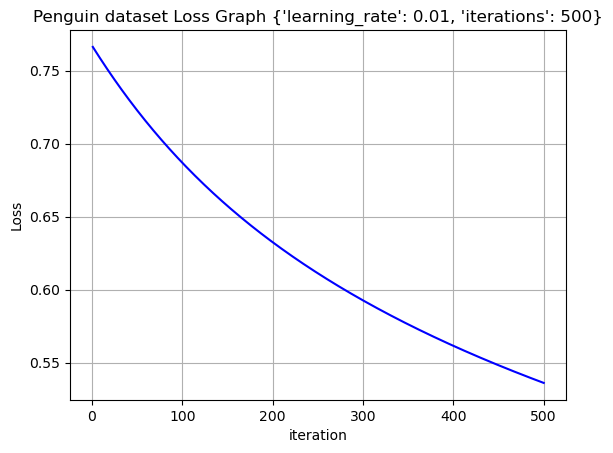

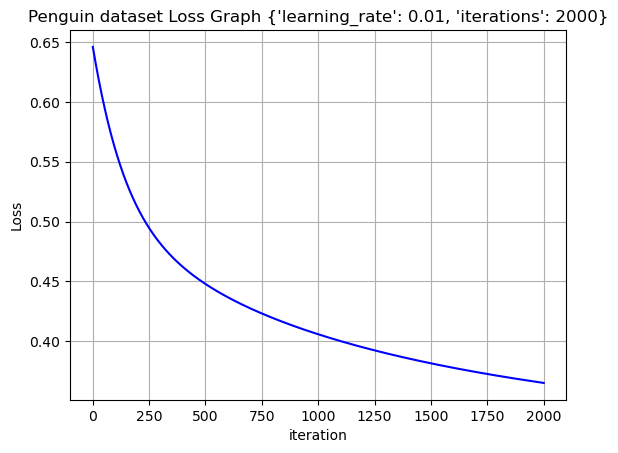

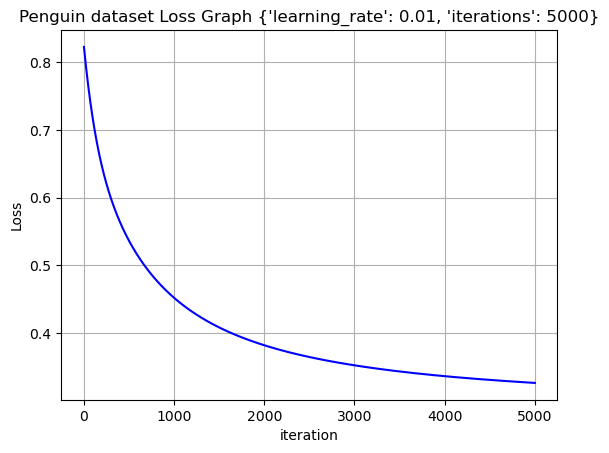

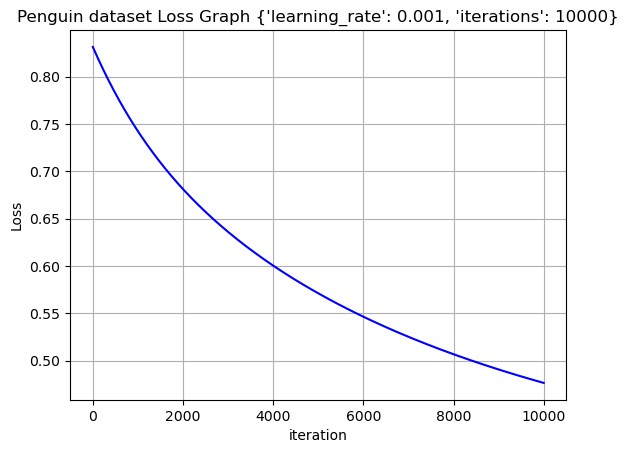

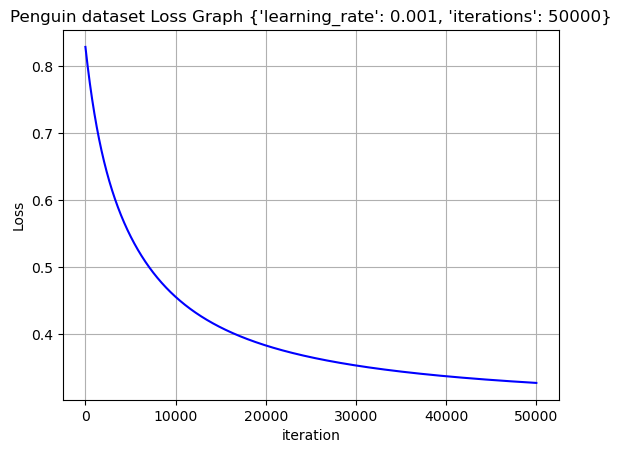

In [32]:
for m in models1:
    x = [x+1 for x in range(len(m['loss_history'])) ]
    plt.plot(x, m['loss_history'], linestyle='-', color='b')
    plt.title(f'Penguin dataset Loss Graph {m['param']}')
    plt.xlabel('iteration')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

Using diamond data

In [8]:
#2. Choose a target Y
#3. Create the data matrices for X (input) and Y (target)
#4. Divide the dataset into training and test, as 80% training and 20% testing dataset.
df_diamond = pd.read_csv('./preprocessed_datasets/df_diamond_preprocessed.csv')
df_diamond_shuffled = df_diamond.sample(frac=1).reset_index(drop=True)

split_index_diamond = int(0.8 * len(df_diamond_shuffled))

X_diamond = df_diamond_shuffled.drop(columns=['cut_Fair', 'cut_Good', 'cut_Premium', 'cut_Very Good', 'cut_Ideal'])
y_diamond = df_diamond_shuffled['cut_Ideal']

X_train_diamond = X_diamond[:split_index_diamond]
y_train_diamond = y_diamond[:split_index_diamond]
X_test_diamond = X_diamond[split_index_diamond:]
y_test_diamond = y_diamond[split_index_diamond:]

In [9]:
#5. Print the shape of X_train, y_train, X_test, y_test
print('shape of diamond X train', X_train_diamond.shape)
print('shape of diamond Y train', y_train_diamond.shape)
print('shape of diamond X test', X_test_diamond.shape)
print('shape of diamond Y test', y_test_diamond.shape)

shape of diamond X train (37943, 15)
shape of diamond Y train (37943,)
shape of diamond X test (9486, 15)
shape of diamond Y test (9486,)


In [10]:
#7. Train the model:
#9. Make a prediction on test dataset by counting how many correct/incorrect predictions your model makes and print your accuracy.(above 64%)
warnings.filterwarnings('ignore')
hyper_parameters2 = [{'learning_rate': 1e-2, 'iterations': 50000}, {'learning_rate': 1e-2, 'iterations': 100000}, {'learning_rate': 1e-3, 'iterations': 50000}, {'learning_rate': 1e-3, 'iterations': 100000}, {'learning_rate': 1e-3, 'iterations': 150000}]
best_accuracy = 0
best_weights = None
best_bias = None
best_loss_history = None
models2=[]
for parameter in hyper_parameters2:
    model = LogitRegression(learning_rate=parameter['learning_rate'], iterations=parameter['iterations'])
    model.fit(X_train_diamond, y_train_diamond)
    model_pred = model.predict(X_test_diamond)
    model_accuracy = np.sum(y_test_diamond == model_pred) / len(y_test_diamond)
    print('Parameters is', parameter, ', and the accuracy of the model is', model_accuracy)
    models2.append({'param': parameter, 'loss_history': model.loss_history})
    if model_accuracy > best_accuracy:
        best_weights = model.weights
        best_bias = model.bias
        best_loss_history = model.loss_history
        best_accuracy = model_accuracy

Parameters is {'learning_rate': 0.01, 'iterations': 50000} , and the accuracy of the model is 0.7347670250896058
Parameters is {'learning_rate': 0.01, 'iterations': 100000} , and the accuracy of the model is 0.765865485979338
Parameters is {'learning_rate': 0.001, 'iterations': 50000} , and the accuracy of the model is 0.6137465738983765
Parameters is {'learning_rate': 0.001, 'iterations': 100000} , and the accuracy of the model is 0.6350411132194813
Parameters is {'learning_rate': 0.001, 'iterations': 150000} , and the accuracy of the model is 0.6691967109424415


In [ ]:
weights_dic['diamond'] = best_weights
bias_dic['diamond'] = best_bias

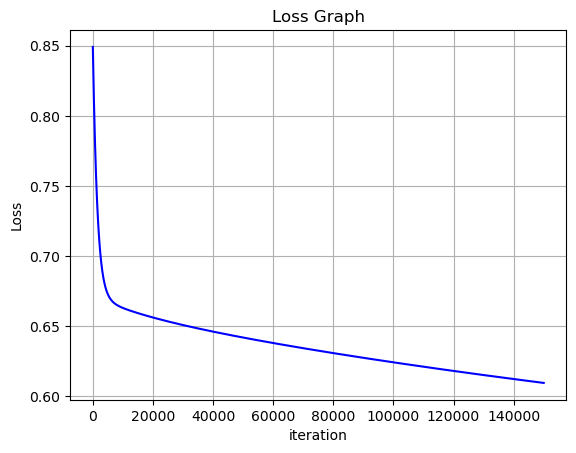

In [26]:
#10. Plot the loss graph and print out the loss values over each iteration.
x = [x+1 for x in range(len(best_loss_history)) ]
plt.plot(x, best_loss_history, linestyle='-', color='b')
plt.title('Loss Graph')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

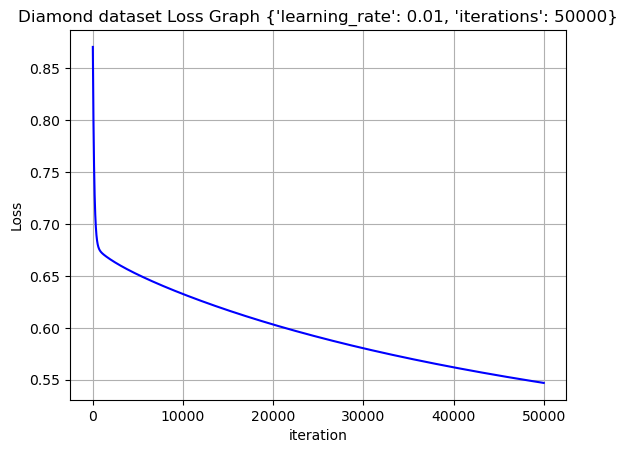

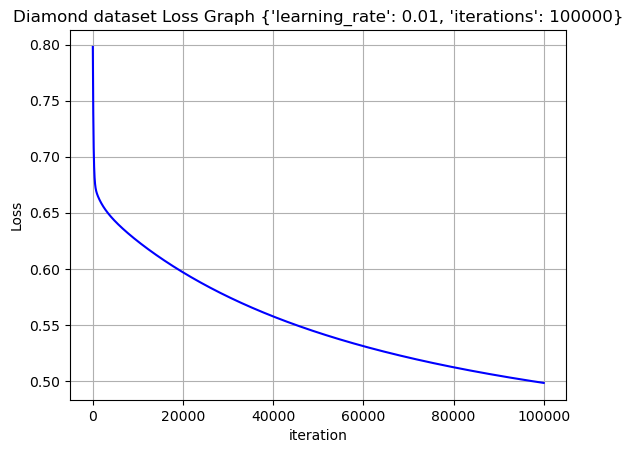

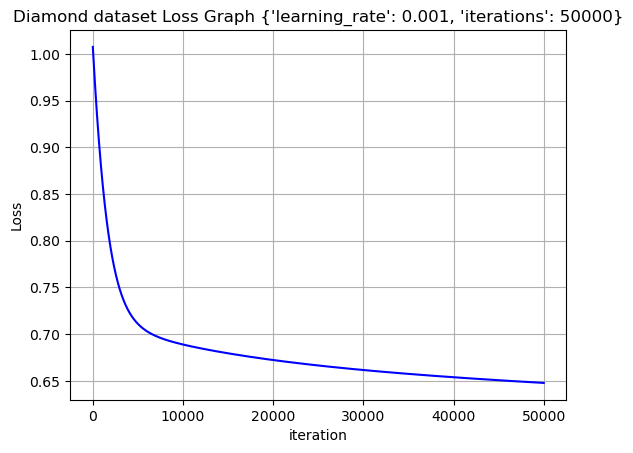

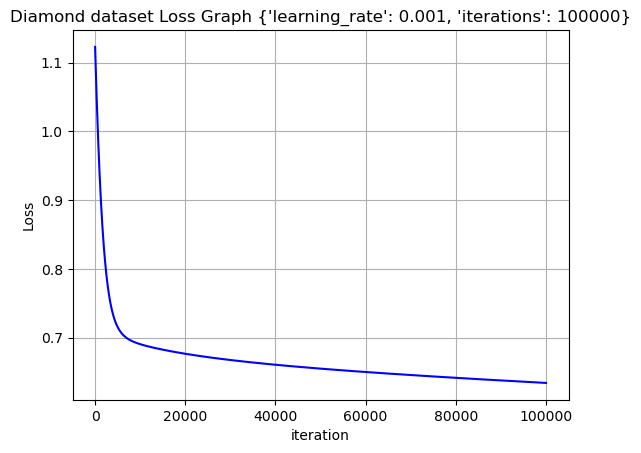

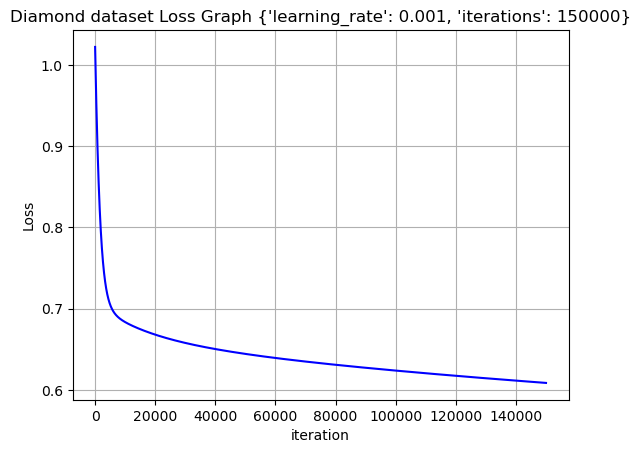

In [12]:
for m in models2:
    x = [x+1 for x in range(len(m['loss_history'])) ]
    plt.plot(x, m['loss_history'], linestyle='-', color='b')
    plt.title(f'Diamond dataset Loss Graph {m['param']}')
    plt.xlabel('iteration')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

Using wine data

In [17]:
#2. Choose a target Y
#3. Create the data matrices for X (input) and Y (target)
#4. Divide the dataset into training and test, as 80% training and 20% testing dataset.
df_wine = pd.read_csv('./preprocessed_datasets/df_wine_preprocessed.csv')
df_wine_shuffled = df_wine.sample(frac=1).reset_index(drop=True)

split_index_wine = int(0.8 * len(df_wine_shuffled))

X_wine = df_wine_shuffled.drop(columns=['type_red', 'type_white'])
y_wine = df_wine_shuffled['type_red']

X_train_wine = X_wine[:split_index_wine]
y_train_wine = y_wine[:split_index_wine]
X_test_wine = X_wine[split_index_wine:]
y_test_wine = y_wine[split_index_wine:]

In [18]:
#5. Print the shape of X_train, y_train, X_test, y_test
print('shape of wine X train', X_train_wine.shape)
print('shape of wine Y train', y_train_wine.shape)
print('shape of wine X test', X_test_wine.shape)
print('shape of wine Y test', y_test_wine.shape)

shape of wine X train (4729, 9)
shape of wine Y train (4729,)
shape of wine X test (1183, 9)
shape of wine Y test (1183,)


In [26]:
#7. Train the model:
#9. Make a prediction on test dataset by counting how many correct/incorrect predictions your model makes and print your accuracy.(above 64%)
warnings.filterwarnings('ignore')
hyper_parameters3 = [{'learning_rate': 1e-3, 'iterations': 100000}, {'learning_rate': 1e-2, 'iterations': 5000}, {'learning_rate': 1e-2, 'iterations': 10000}, {'learning_rate': 1e-2, 'iterations': 20000}]
best_accuracy = 0
best_weights = None
best_bias = None
best_loss_history = None
models3=[]
for parameter in hyper_parameters3:
    model = LogitRegression(learning_rate=parameter['learning_rate'], iterations=parameter['iterations'])
    model.fit(X_train_wine, y_train_wine)
    model_pred = model.predict(X_test_wine)
    model_accuracy = np.sum(y_test_wine == model_pred) / len(y_test_wine)
    print('Parameters is', parameter, ', and the accuracy of the model is', model_accuracy)
    models3.append({'param': parameter, 'loss_history': model.loss_history})
    if model_accuracy > best_accuracy:
        best_weights = model.weights
        best_bias = model.bias
        best_loss_history = model.loss_history
        best_accuracy = model_accuracy

Parameters is {'learning_rate': 0.001, 'iterations': 100000} , and the accuracy of the model is 0.9205409974640744
Parameters is {'learning_rate': 0.01, 'iterations': 5000} , and the accuracy of the model is 0.8072696534234995
Parameters is {'learning_rate': 0.01, 'iterations': 10000} , and the accuracy of the model is 0.9213863060016906
Parameters is {'learning_rate': 0.01, 'iterations': 20000} , and the accuracy of the model is 0.959425190194421


In [37]:
weights_dic['wine'] = best_weights
bias_dic['wine'] = best_bias

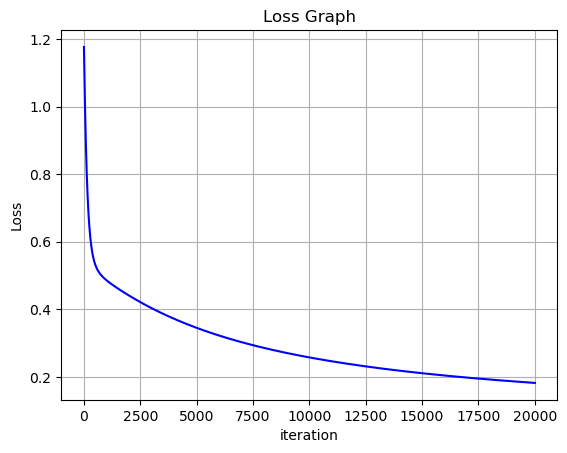

In [20]:
#10. Plot the loss graph and print out the loss values over each iteration.
x = [x+1 for x in range(len(best_loss_history)) ]
plt.plot(x, best_loss_history, linestyle='-', color='b')
plt.title('Loss Graph')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

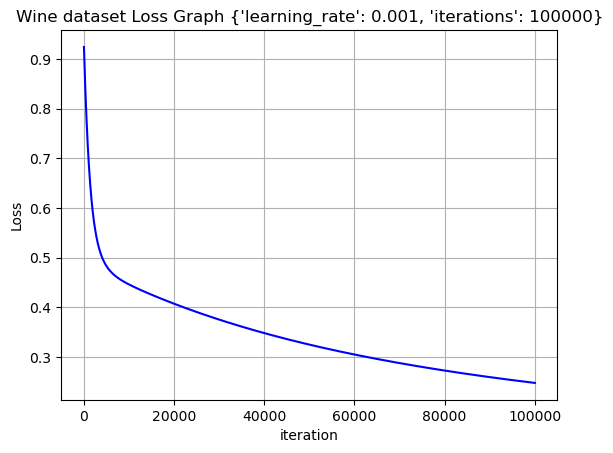

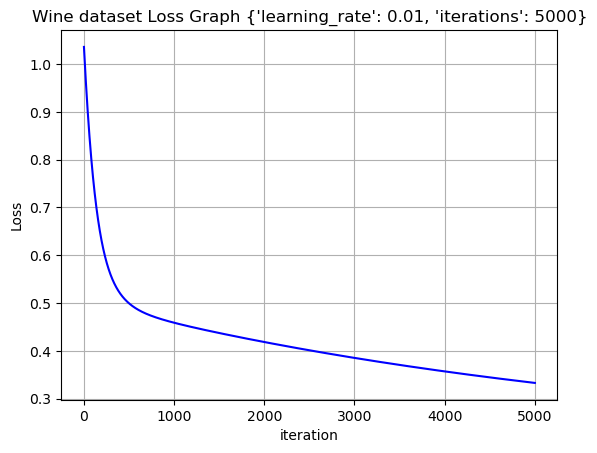

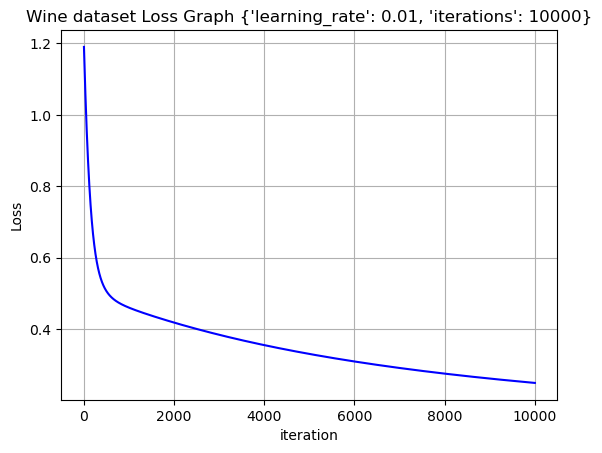

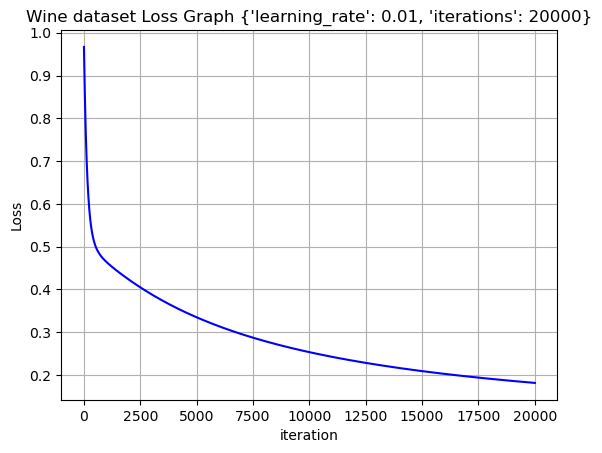

In [27]:
for m in models3:
    x = [x+1 for x in range(len(m['loss_history'])) ]
    plt.plot(x, m['loss_history'], linestyle='-', color='b')
    plt.title(f'Wine dataset Loss Graph {m['param']}')
    plt.xlabel('iteration')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

In [40]:
#8. Save the weights of the model, that returns the highest accuracy as pickle file.    
with open('heejuhwa_weights_assignment1_part2.pickle', 'wb') as file:
    pickle.dump(weights_dic, file)
with open('heejuhwa_bias_assignment1_part2.pickle', 'wb') as file:
    pickle.dump(bias_dic, file)

Reference

*   https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html
*   https://numpy.org/doc/stable/reference/generated/numpy.array.html
*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html
*   https://numpy.org/doc/stable/reference/generated/numpy.log.html#numpy.log
*   https://numpy.org/doc/2.0/reference/generated/numpy.exp.html
*   https://numpy.org/doc/stable/reference/generated/numpy.clip.html
*   https://docs.python.org/3/library/pickle.html
*   